# PA-100K Dataset Construction
## Attribute-Aware Training Subset Creation

This notebook constructs a computationally manageable training subset from the PA-100K dataset.

### Motivation

The original PA-100K training split contains 80,000 pedestrian images.

Training on the complete dataset is computationally expensive for the current project. However, naive random subsampling may remove too many positive examples from rare pedestrian attributes.

Therefore, this notebook develops an **attribute-aware subset construction strategy**.

### Objectives

1. Load the official PA-100K train/validation/test splits.
2. Retain the selected pedestrian attributes identified during EDA.
3. Compare random subsets of different sizes.
4. Measure minority-attribute retention.
5. Construct an attribute-aware subset.
6. Compare the new subset against the original training distribution.
7. Verify that label relationships remain valid.
8. Save the final subset for model training.

### Important Constraint

Validation and test sets will remain **unchanged**.

Only the training set will be reduced.

## Imports

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
rng = np.random.default_rng(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


## Paths

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "PA-100K"

TRAIN_PATH = DATA_DIR / "train.csv"
VAL_PATH = DATA_DIR / "val.csv"
TEST_PATH = DATA_DIR / "test.csv"

OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Dataset Dir  :", DATA_DIR)
print("Output Dir   :", OUTPUT_DIR)

Project Root : /Users/sanchitthakur/Desktop/PAR
Dataset Dir  : /Users/sanchitthakur/Desktop/PAR/PA-100K
Output Dir   : /Users/sanchitthakur/Desktop/PAR/PA-100K/processed


## Load dataset

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

Train      : (80000, 27)
Validation : (10000, 27)
Test       : (10000, 27)


## Selected attributes

In [5]:
SELECTED_ATTRIBUTES = [
    # Binary demographic
    "Female",

    # Orientation
    "Front",
    "Side",
    "Back",

    # Sleeve
    "ShortSleeve",
    "LongSleeve",

    # Accessories
    "Hat",
    "Glasses",
    "HandBag",
    "ShoulderBag",
    "Backpack",

    # Upper clothing
    "UpperLogo",
    "UpperPlaid",

    # Lower clothing
    "Trousers",
    "Shorts",
    "Skirt&Dress",
]

SELECTED_COLUMNS = ["Image"] + SELECTED_ATTRIBUTES

print(f"Selected raw attributes: {len(SELECTED_ATTRIBUTES)}")

for attr in SELECTED_ATTRIBUTES:
    print("-", attr)

Selected raw attributes: 16
- Female
- Front
- Side
- Back
- ShortSleeve
- LongSleeve
- Hat
- Glasses
- HandBag
- ShoulderBag
- Backpack
- UpperLogo
- UpperPlaid
- Trousers
- Shorts
- Skirt&Dress


## Create working dataframes

In [6]:
train_selected = train_df[SELECTED_COLUMNS].copy()
val_selected = val_df[SELECTED_COLUMNS].copy()
test_selected = test_df[SELECTED_COLUMNS].copy()

print("Selected dataframes created.")

print("Train :", train_selected.shape)
print("Val   :", val_selected.shape)
print("Test  :", test_selected.shape)

Selected dataframes created.
Train : (80000, 17)
Val   : (10000, 17)
Test  : (10000, 17)


## Original training distribution

In [7]:
def prevalence_table(df, attributes):
    rows = []

    for attr in attributes:
        positive = int(df[attr].sum())
        negative = len(df) - positive
        prevalence = positive / len(df) * 100

        rows.append({
            "Attribute": attr,
            "Positive": positive,
            "Negative": negative,
            "Positive %": prevalence
        })

    return pd.DataFrame(rows)

original_distribution = prevalence_table(
    train_selected,
    SELECTED_ATTRIBUTES
)

display(
    original_distribution
    .sort_values("Positive %")
    .style.format({
        "Positive": "{:,}",
        "Negative": "{:,}",
        "Positive %": "{:.2f}%"
    })
)

,Attribute,Positive,Negative,Positive %
6,Hat,"3,516","76,484",4.40%
12,UpperPlaid,"8,690","71,310",10.86%
15,Skirt&Dress,"9,371","70,629",11.71%
10,Backpack,"11,807","68,193",14.76%
11,UpperLogo,"12,323","67,677",15.40%
14,Shorts,"13,910","66,090",17.39%
7,Glasses,"14,331","65,669",17.91%
8,HandBag,"14,680","65,320",18.35%
9,ShoulderBag,"15,290","64,710",19.11%
2,Side,"22,706","57,294",28.38%


## Visualize original selected attributes

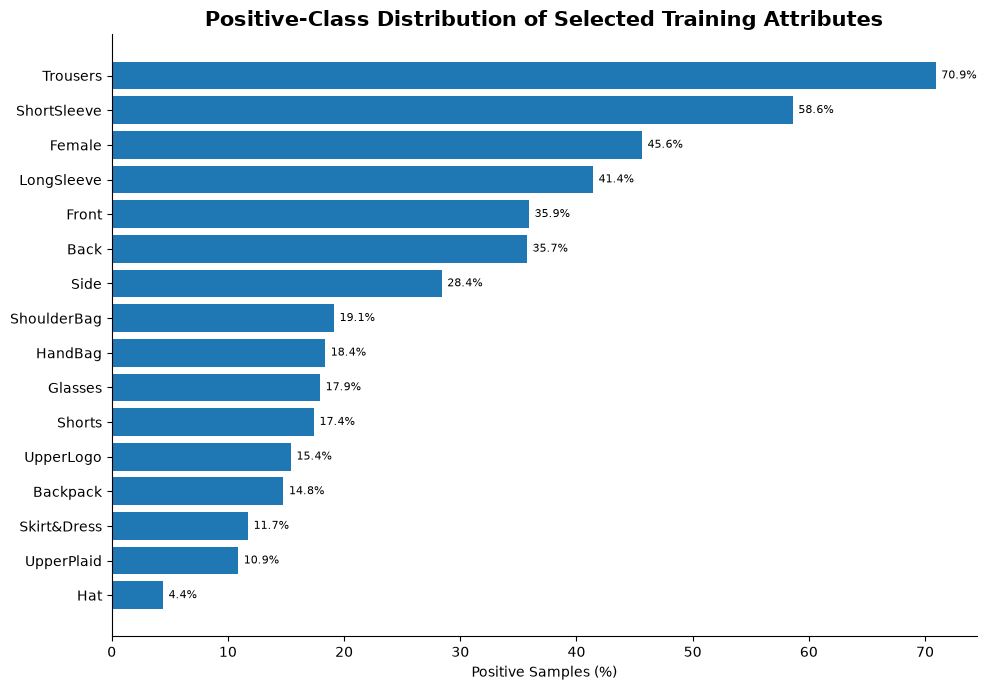

In [8]:
plot_df = original_distribution.sort_values("Positive %")

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_df["Attribute"],
    plot_df["Positive %"]
)

ax.set_title(
    "Positive-Class Distribution of Selected Training Attributes",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Positive Samples (%)")

for bar, value in zip(bars, plot_df["Positive %"]):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Baseline Training Distribution

The selected attributes intentionally contain different levels of class imbalance.

This is desirable because the project aims to evaluate whether imbalance-aware training methods improve performance for minority attributes.

The reduced subset should therefore:

- retain the natural multi-label structure,
- preserve sufficient minority examples,
- avoid artificially forcing every attribute toward a 50:50 distribution,
- and remain substantially smaller than the original 80,000-image training split.

## Test naive random subset sizes

In [9]:
CANDIDATE_SIZES = [
    10_000,
    15_000,
    20_000,
    25_000,
    30_000
]

random_subset_results = []

for size in CANDIDATE_SIZES:

    subset = train_selected.sample(
        n=size,
        random_state=SEED
    )

    for attr in SELECTED_ATTRIBUTES:

        original_pos = int(train_selected[attr].sum())
        subset_pos = int(subset[attr].sum())

        original_pct = train_selected[attr].mean() * 100
        subset_pct = subset[attr].mean() * 100

        random_subset_results.append({
            "Subset Size": size,
            "Attribute": attr,
            "Original Positives": original_pos,
            "Subset Positives": subset_pos,
            "Original %": original_pct,
            "Subset %": subset_pct,
            "Prevalence Difference": subset_pct - original_pct,
            "Positive Retention %": (
                subset_pos / original_pos * 100
            )
        })

random_subset_results = pd.DataFrame(random_subset_results)

## Show rare label retention

In [10]:
RARE_ATTRIBUTES = [
    "Hat",
    "UpperPlaid"
]

rare_random_comparison = random_subset_results[
    random_subset_results["Attribute"].isin(RARE_ATTRIBUTES)
]

display(
    rare_random_comparison.style.format({
        "Original Positives": "{:,}",
        "Subset Positives": "{:,}",
        "Original %": "{:.2f}%",
        "Subset %": "{:.2f}%",
        "Prevalence Difference": "{:+.2f} pp",
        "Positive Retention %": "{:.1f}%"
    })
)

,Subset Size,Attribute,Original Positives,Subset Positives,Original %,Subset %,Prevalence Difference,Positive Retention %
6,10000,Hat,"3,516",433,4.40%,4.33%,-0.07 pp,12.3%
12,10000,UpperPlaid,"8,690","1,105",10.86%,11.05%,+0.19 pp,12.7%
22,15000,Hat,"3,516",658,4.40%,4.39%,-0.01 pp,18.7%
28,15000,UpperPlaid,"8,690","1,629",10.86%,10.86%,-0.00 pp,18.7%
38,20000,Hat,"3,516",895,4.40%,4.47%,+0.08 pp,25.5%
44,20000,UpperPlaid,"8,690","2,204",10.86%,11.02%,+0.16 pp,25.4%
54,25000,Hat,"3,516","1,125",4.40%,4.50%,+0.10 pp,32.0%
60,25000,UpperPlaid,"8,690","2,752",10.86%,11.01%,+0.15 pp,31.7%
70,30000,Hat,"3,516","1,357",4.40%,4.52%,+0.13 pp,38.6%
76,30000,UpperPlaid,"8,690","3,284",10.86%,10.95%,+0.08 pp,37.8%


## Plot expected positives across subset sizes

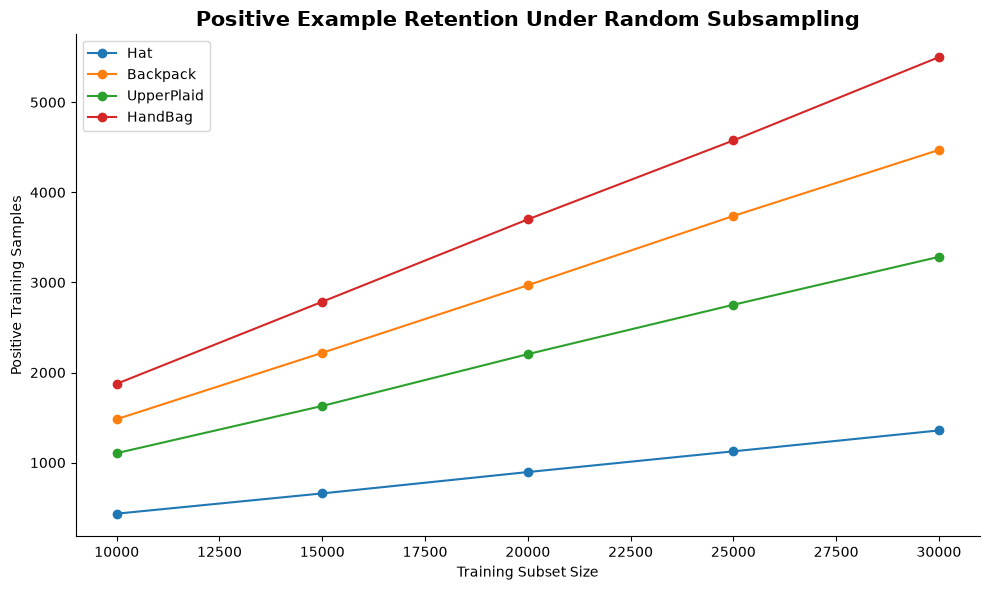

In [11]:
plot_attrs = [
    "Hat",
    "Backpack",
    "UpperPlaid",
    "HandBag"
]

fig, ax = plt.subplots(figsize=(10, 6))

for attr in plot_attrs:

    temp = random_subset_results[
        random_subset_results["Attribute"] == attr
    ]

    ax.plot(
        temp["Subset Size"],
        temp["Subset Positives"],
        marker="o",
        label=attr
    )

ax.set_title(
    "Positive Example Retention Under Random Subsampling",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Training Subset Size")
ax.set_ylabel("Positive Training Samples")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Why Random Sampling Is Not Ideal

Random sampling preserves the overall dataset distribution reasonably well, but it also reduces minority examples almost proportionally to the size reduction.

For common attributes this is not a major issue.

For rare attributes, however, reducing the training set to 10K–20K may substantially reduce the diversity of available positive samples.

The next step therefore introduces an **attribute-aware sampling strategy** that increases exposure to selected minority attributes without forcing unrealistic class balance.

## Define minority attributes for preservation

In [12]:
MINORITY_PRIORITY_ATTRIBUTES = [
    "Hat",
    "UpperPlaid",
    "Backpack",
    "UpperLogo",
    "HandBag",
    "ShoulderBag",
    "Glasses",
    "Shorts",
    "Skirt&Dress",
]

print("Priority minority attributes:")

for attr in MINORITY_PRIORITY_ATTRIBUTES:
    pct = train_selected[attr].mean() * 100

    print(
        f"{attr:15s} : "
        f"{train_selected[attr].sum():,} positives "
        f"({pct:.2f}%)"
    )

Priority minority attributes:
Hat             : 3,516 positives (4.40%)
UpperPlaid      : 8,690 positives (10.86%)
Backpack        : 11,807 positives (14.76%)
UpperLogo       : 12,323 positives (15.40%)
HandBag         : 14,680 positives (18.35%)
ShoulderBag     : 15,290 positives (19.11%)
Glasses         : 14,331 positives (17.91%)
Shorts          : 13,910 positives (17.39%)
Skirt&Dress     : 9,371 positives (11.71%)


## Attribute rarity score

In [13]:
attribute_prevalence = {
    attr: train_selected[attr].mean()
    for attr in SELECTED_ATTRIBUTES
}

attribute_weights = {}

for attr in SELECTED_ATTRIBUTES:

    prevalence = attribute_prevalence[attr]

    # Higher weight for rarer positive attributes
    attribute_weights[attr] = 1 / np.sqrt(
        max(prevalence, 1e-6)
    )

attribute_weights

{'Female': np.float64(1.4806286899655334),
 'Front': np.float64(1.669044430574984),
 'Side': np.float64(1.8770449666289604),
 'Back': np.float64(1.6731862035256366),
 'ShortSleeve': np.float64(1.3063527268659332),
 'LongSleeve': np.float64(1.5541277569616463),
 'Hat': np.float64(4.770023957505489),
 'Glasses': np.float64(2.362690012679537),
 'HandBag': np.float64(2.334435966278354),
 'ShoulderBag': np.float64(2.287395438932324),
 'Backpack': np.float64(2.6030062559588716),
 'UpperLogo': np.float64(2.5479257578373646),
 'UpperPlaid': np.float64(3.0341364322535322),
 'Trousers': np.float64(1.1876287730795256),
 'Shorts': np.float64(2.3981780767296423),
 'Skirt&Dress': np.float64(2.9218103594058316)}

## Calculate image sampling score

In [14]:
def calculate_sampling_score(row):

    score = 1.0

    for attr in SELECTED_ATTRIBUTES:

        if row[attr] == 1:
            score += attribute_weights[attr]

    return score


train_scored = train_selected.copy()

train_scored["sampling_score"] = train_scored.apply(
    calculate_sampling_score,
    axis=1
)

display(
    train_scored[
        ["Image", "sampling_score"] + SELECTED_ATTRIBUTES
    ]
    .sort_values(
        "sampling_score",
        ascending=False
    )
    .head(10)
)

,Image,sampling_score,Female,Front,Side,Back,ShortSleeve,LongSleeve,Hat,Glasses,HandBag,ShoulderBag,Backpack,UpperLogo,UpperPlaid,Trousers,Shorts,Skirt&Dress
78787,078788.jpg,18.716,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1
41455,041456.jpg,18.612,1,1,0,0,1,0,1,1,0,1,0,1,0,1,0,0
32521,032522.jpg,18.396,1,1,0,0,1,0,0,1,1,1,0,0,1,0,0,1
68749,068750.jpg,18.118,1,0,1,0,1,0,0,1,1,1,0,1,0,0,0,1
38656,038657.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1
11705,011706.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1
42609,042610.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1
38692,038693.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1
17376,017377.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1
16063,016064.jpg,17.910,1,1,0,0,1,0,0,1,1,1,0,1,0,0,0,1


## Inspect score distribution

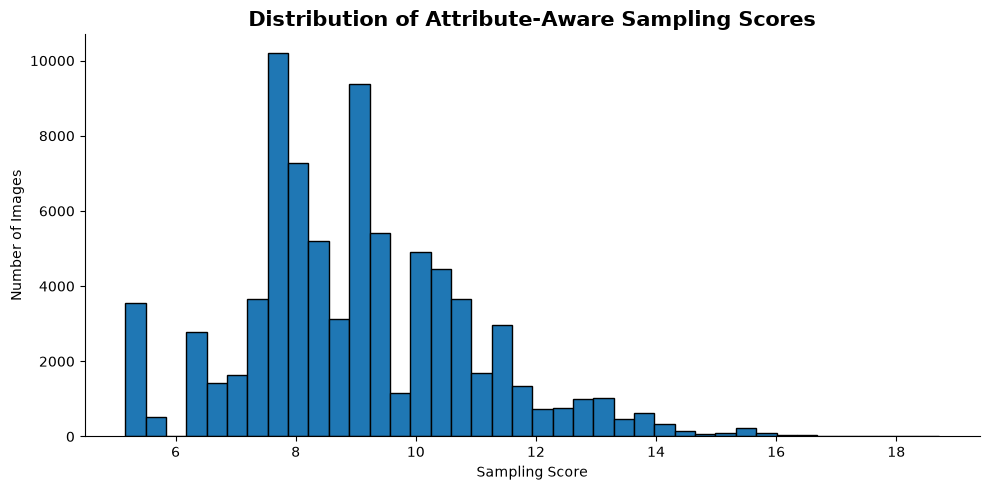

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    train_scored["sampling_score"],
    bins=40,
    edgecolor="black"
)

ax.set_title(
    "Distribution of Attribute-Aware Sampling Scores",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Sampling Score")
ax.set_ylabel("Number of Images")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Create weighted subsets

In [16]:
weighted_subsets = {}

sampling_probability = (
    train_scored["sampling_score"]
    /
    train_scored["sampling_score"].sum()
)

for size in CANDIDATE_SIZES:

    sampled_indices = rng.choice(
        train_scored.index,
        size=size,
        replace=False,
        p=sampling_probability
    )

    subset = (
        train_scored
        .loc[sampled_indices]
        .drop(columns="sampling_score")
        .reset_index(drop=True)
    )

    weighted_subsets[size] = subset

print("Weighted candidate subsets created.")

Weighted candidate subsets created.


## Compare weighted subset distributions

In [17]:
weighted_results = []

for size, subset in weighted_subsets.items():

    for attr in SELECTED_ATTRIBUTES:

        original_pos = int(train_selected[attr].sum())
        subset_pos = int(subset[attr].sum())

        original_pct = train_selected[attr].mean() * 100
        subset_pct = subset[attr].mean() * 100

        weighted_results.append({
            "Subset Size": size,
            "Attribute": attr,
            "Original Positives": original_pos,
            "Subset Positives": subset_pos,
            "Original %": original_pct,
            "Subset %": subset_pct,
            "Prevalence Difference": subset_pct - original_pct,
            "Positive Retention %": (
                subset_pos / original_pos * 100
            )
        })

weighted_results = pd.DataFrame(weighted_results)

## Compare random vs attribute-aware sampling

In [18]:
TARGET_SIZE = 20_000

random_20k = random_subset_results[
    random_subset_results["Subset Size"] == TARGET_SIZE
][
    [
        "Attribute",
        "Subset Positives",
        "Subset %"
    ]
].rename(
    columns={
        "Subset Positives": "Random Positives",
        "Subset %": "Random %"
    }
)

weighted_20k = weighted_results[
    weighted_results["Subset Size"] == TARGET_SIZE
][
    [
        "Attribute",
        "Subset Positives",
        "Subset %"
    ]
].rename(
    columns={
        "Subset Positives": "Weighted Positives",
        "Subset %": "Weighted %"
    }
)

comparison_20k = (
    original_distribution[
        [
            "Attribute",
            "Positive",
            "Positive %"
        ]
    ]
    .rename(
        columns={
            "Positive": "Original Positives",
            "Positive %": "Original %"
        }
    )
    .merge(
        random_20k,
        on="Attribute"
    )
    .merge(
        weighted_20k,
        on="Attribute"
    )
)

comparison_20k["Additional Positives"] = (
    comparison_20k["Weighted Positives"]
    -
    comparison_20k["Random Positives"]
)

display(
    comparison_20k
    .sort_values("Original %")
    .style.format({
        "Original Positives": "{:,}",
        "Original %": "{:.2f}%",
        "Random Positives": "{:,}",
        "Random %": "{:.2f}%",
        "Weighted Positives": "{:,}",
        "Weighted %": "{:.2f}%",
        "Additional Positives": "{:+,}"
    })
)

,Attribute,Original Positives,Original %,Random Positives,Random %,Weighted Positives,Weighted %,Additional Positives
6,Hat,"3,516",4.40%,895,4.47%,"1,034",5.17%,+139
12,UpperPlaid,"8,690",10.86%,"2,204",11.02%,"2,400",12.00%,+196
15,Skirt&Dress,"9,371",11.71%,"2,331",11.65%,"2,638",13.19%,+307
10,Backpack,"11,807",14.76%,"2,969",14.85%,"3,275",16.38%,+306
11,UpperLogo,"12,323",15.40%,"3,052",15.26%,"3,384",16.92%,+332
14,Shorts,"13,910",17.39%,"3,482",17.41%,"3,578",17.89%,+96
7,Glasses,"14,331",17.91%,"3,640",18.20%,"3,679",18.39%,+39
8,HandBag,"14,680",18.35%,"3,700",18.50%,"4,091",20.46%,+391
9,ShoulderBag,"15,290",19.11%,"3,809",19.05%,"4,247",21.23%,+438
2,Side,"22,706",28.38%,"5,737",28.68%,"5,703",28.52%,-34


## Visual comparison

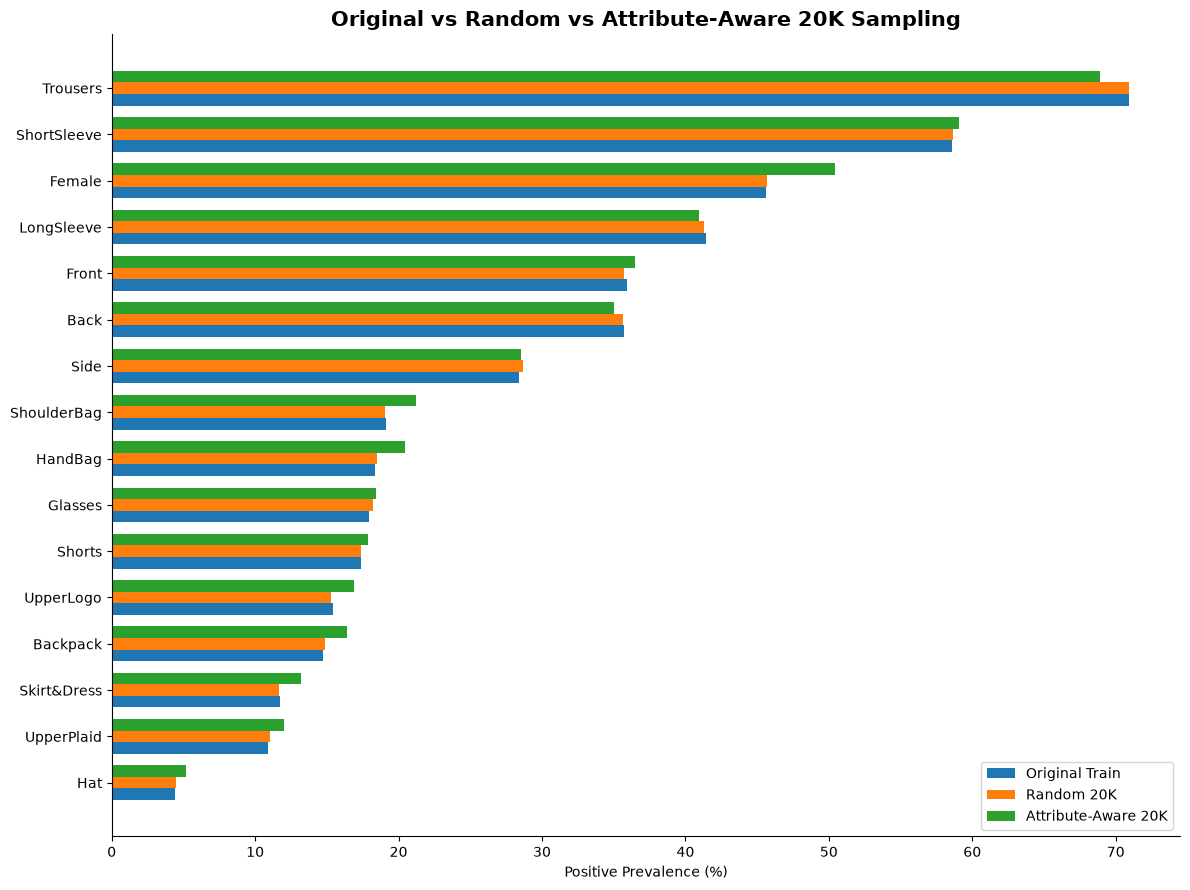

In [19]:
comparison_plot = comparison_20k.sort_values(
    "Original %",
    ascending=True
)

y = np.arange(len(comparison_plot))
height = 0.25

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    y - height,
    comparison_plot["Original %"],
    height,
    label="Original Train"
)

ax.barh(
    y,
    comparison_plot["Random %"],
    height,
    label="Random 20K"
)

ax.barh(
    y + height,
    comparison_plot["Weighted %"],
    height,
    label="Attribute-Aware 20K"
)

ax.set_yticks(y)
ax.set_yticklabels(
    comparison_plot["Attribute"]
)

ax.set_xlabel("Positive Prevalence (%)")

ax.set_title(
    "Original vs Random vs Attribute-Aware 20K Sampling",
    fontsize=15,
    fontweight="bold"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Check distribution distortion

In [20]:
weighted_20k_distribution = comparison_20k.copy()

weighted_20k_distribution["Absolute Shift"] = abs(
    weighted_20k_distribution["Weighted %"]
    -
    weighted_20k_distribution["Original %"]
)

display(
    weighted_20k_distribution[
        [
            "Attribute",
            "Original %",
            "Weighted %",
            "Absolute Shift"
        ]
    ]
    .sort_values(
        "Absolute Shift",
        ascending=False
    )
    .style.format({
        "Original %": "{:.2f}%",
        "Weighted %": "{:.2f}%",
        "Absolute Shift": "{:.2f} pp"
    })
)

,Attribute,Original %,Weighted %,Absolute Shift
0,Female,45.62%,50.43%,4.81 pp
9,ShoulderBag,19.11%,21.23%,2.12 pp
8,HandBag,18.35%,20.46%,2.11 pp
13,Trousers,70.90%,68.92%,1.98 pp
10,Backpack,14.76%,16.38%,1.62 pp
11,UpperLogo,15.40%,16.92%,1.52 pp
15,Skirt&Dress,11.71%,13.19%,1.48 pp
12,UpperPlaid,10.86%,12.00%,1.14 pp
6,Hat,4.40%,5.17%,0.77 pp
3,Back,35.72%,34.99%,0.73 pp


## Check categorical group validity

In [21]:
ATTRIBUTE_GROUPS = {
    "Orientation": [
        "Front",
        "Side",
        "Back"
    ],

    "Sleeve": [
        "ShortSleeve",
        "LongSleeve"
    ],

    "Lower Clothing": [
        "Trousers",
        "Shorts",
        "Skirt&Dress"
    ]
}

candidate_subset = weighted_subsets[TARGET_SIZE]

group_checks = []

for group_name, cols in ATTRIBUTE_GROUPS.items():

    counts = candidate_subset[cols].sum(axis=1)

    group_checks.append({
        "Group": group_name,
        "Exactly One": int((counts == 1).sum()),
        "None": int((counts == 0).sum()),
        "Multiple": int((counts > 1).sum()),
        "Exactly One %": (
            (counts == 1).mean() * 100
        )
    })

group_check_df = pd.DataFrame(group_checks)

display(
    group_check_df.style.format({
        "Exactly One": "{:,}",
        "None": "{:,}",
        "Multiple": "{:,}",
        "Exactly One %": "{:.3f}%"
    })
)

,Group,Exactly One,None,Multiple,Exactly One %
0,Orientation,"20,000",0,0,100.000%
1,Sleeve,"20,000",0,0,100.000%
2,Lower Clothing,"20,000",0,0,100.000%


## Check duplicate image names

In [22]:
print(
    "Duplicate images:",
    candidate_subset["Image"].duplicated().sum()
)

print(
    "Total images:",
    len(candidate_subset)
)

print(
    "Unique images:",
    candidate_subset["Image"].nunique()
)

Duplicate images: 0
Total images: 20000
Unique images: 20000


## Check image overlap with validation/test

In [23]:
train_images = set(candidate_subset["Image"])
val_images = set(val_selected["Image"])
test_images = set(test_selected["Image"])

train_val_overlap = train_images & val_images
train_test_overlap = train_images & test_images
val_test_overlap = val_images & test_images

print(
    "Train ↔ Validation overlap:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test overlap:",
    len(val_test_overlap)
)

Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


## Compare candidate sizes systematically

In [24]:
candidate_summary = []

for size in CANDIDATE_SIZES:

    temp = weighted_results[
        weighted_results["Subset Size"] == size
    ].copy()

    mean_shift = abs(
        temp["Prevalence Difference"]
    ).mean()

    max_shift = abs(
        temp["Prevalence Difference"]
    ).max()

    hat_pos = int(
        temp.loc[
            temp["Attribute"] == "Hat",
            "Subset Positives"
        ].iloc[0]
    )

    backpack_pos = int(
        temp.loc[
            temp["Attribute"] == "Backpack",
            "Subset Positives"
        ].iloc[0]
    )

    candidate_summary.append({
        "Subset Size": size,
        "Mean Distribution Shift": mean_shift,
        "Max Distribution Shift": max_shift,
        "Hat Positives": hat_pos,
        "Backpack Positives": backpack_pos
    })

candidate_summary = pd.DataFrame(candidate_summary)

display(
    candidate_summary.style.format({
        "Subset Size": "{:,}",
        "Mean Distribution Shift": "{:.2f} pp",
        "Max Distribution Shift": "{:.2f} pp",
        "Hat Positives": "{:,}",
        "Backpack Positives": "{:,}"
    })
)

,Subset Size,Mean Distribution Shift,Max Distribution Shift,Hat Positives,Backpack Positives
0,"10,000",1.52 pp,4.76 pp,481,"1,626"
1,"15,000",1.39 pp,4.34 pp,741,"2,411"
2,"20,000",1.31 pp,4.81 pp,"1,034","3,275"
3,"25,000",1.25 pp,4.34 pp,"1,282","3,980"
4,"30,000",1.12 pp,3.71 pp,"1,455","4,640"


## Plot tradeoff

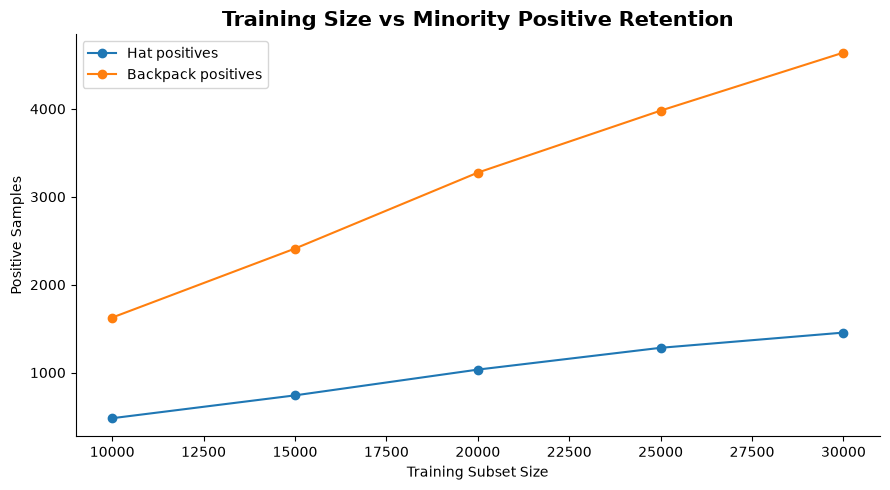

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    candidate_summary["Subset Size"],
    candidate_summary["Hat Positives"],
    marker="o",
    label="Hat positives"
)

ax.plot(
    candidate_summary["Subset Size"],
    candidate_summary["Backpack Positives"],
    marker="o",
    label="Backpack positives"
)

ax.set_title(
    "Training Size vs Minority Positive Retention",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Training Subset Size")
ax.set_ylabel("Positive Samples")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Candidate Dataset Selection

The final subset size should balance two competing objectives:

### Computational efficiency

A smaller dataset reduces:

- training time,
- GPU memory requirements,
- experiment turnaround time,
- and cost of repeated loss-function comparisons.

### Minority-class representation

A larger subset preserves:

- more positive examples,
- greater appearance diversity,
- and more reliable minority-attribute learning.

The candidate sizes evaluated are:

- 10K
- 15K
- 20K
- 25K
- 30K

The final size will be selected based on:

1. minority positive counts,
2. distribution distortion,
3. multi-label consistency,
4. and available computational resources.

## Choose final size

In [26]:
FINAL_TRAIN_SIZE = 20_000

final_train = (
    weighted_subsets[FINAL_TRAIN_SIZE]
    .copy()
    .reset_index(drop=True)
)

print("Final training subset:", final_train.shape)

Final training subset: (20000, 17)


## Shuffle final dataset

In [27]:
final_train = final_train.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

display(final_train.head())

,Image,Female,Front,Side,Back,ShortSleeve,LongSleeve,Hat,Glasses,HandBag,ShoulderBag,Backpack,UpperLogo,UpperPlaid,Trousers,Shorts,Skirt&Dress
0,060746.jpg,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1
1,009637.jpg,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0
2,044860.jpg,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0
3,033403.jpg,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0
4,063244.jpg,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0


## Final train distribution

In [28]:
final_distribution = prevalence_table(
    final_train,
    SELECTED_ATTRIBUTES
)

final_comparison = (
    original_distribution[
        [
            "Attribute",
            "Positive",
            "Positive %"
        ]
    ]
    .rename(
        columns={
            "Positive": "Original Positives",
            "Positive %": "Original %"
        }
    )
    .merge(
        final_distribution[
            [
                "Attribute",
                "Positive",
                "Positive %"
            ]
        ].rename(
            columns={
                "Positive": "Final Positives",
                "Positive %": "Final %"
            }
        ),
        on="Attribute"
    )
)

final_comparison["Shift"] = (
    final_comparison["Final %"]
    -
    final_comparison["Original %"]
)

display(
    final_comparison
    .sort_values("Original %")
    .style.format({
        "Original Positives": "{:,}",
        "Original %": "{:.2f}%",
        "Final Positives": "{:,}",
        "Final %": "{:.2f}%",
        "Shift": "{:+.2f} pp"
    })
)

,Attribute,Original Positives,Original %,Final Positives,Final %,Shift
6,Hat,"3,516",4.40%,"1,034",5.17%,+0.77 pp
12,UpperPlaid,"8,690",10.86%,"2,400",12.00%,+1.14 pp
15,Skirt&Dress,"9,371",11.71%,"2,638",13.19%,+1.48 pp
10,Backpack,"11,807",14.76%,"3,275",16.38%,+1.62 pp
11,UpperLogo,"12,323",15.40%,"3,384",16.92%,+1.52 pp
14,Shorts,"13,910",17.39%,"3,578",17.89%,+0.50 pp
7,Glasses,"14,331",17.91%,"3,679",18.39%,+0.48 pp
8,HandBag,"14,680",18.35%,"4,091",20.46%,+2.11 pp
9,ShoulderBag,"15,290",19.11%,"4,247",21.23%,+2.12 pp
2,Side,"22,706",28.38%,"5,703",28.52%,+0.13 pp


## Keep validation/test unchanged

In [29]:
final_val = val_selected.copy()
final_test = test_selected.copy()

print("Final Train :", final_train.shape)
print("Final Val   :", final_val.shape)
print("Final Test  :", final_test.shape)

Final Train : (20000, 17)
Final Val   : (10000, 17)
Final Test  : (10000, 17)


## Save the datasets

In [30]:
TRAIN_OUTPUT = OUTPUT_DIR / "train_selected.csv"
VAL_OUTPUT = OUTPUT_DIR / "val_selected.csv"
TEST_OUTPUT = OUTPUT_DIR / "test_selected.csv"

final_train.to_csv(
    TRAIN_OUTPUT,
    index=False
)

final_val.to_csv(
    VAL_OUTPUT,
    index=False
)

final_test.to_csv(
    TEST_OUTPUT,
    index=False
)

print("Saved:")
print(TRAIN_OUTPUT)
print(VAL_OUTPUT)
print(TEST_OUTPUT)

Saved:
/Users/sanchitthakur/Desktop/PAR/PA-100K/processed/train_selected.csv
/Users/sanchitthakur/Desktop/PAR/PA-100K/processed/val_selected.csv
/Users/sanchitthakur/Desktop/PAR/PA-100K/processed/test_selected.csv


## Metadata

In [33]:
metadata = pd.DataFrame({
    "Setting": [
        "Random Seed",
        "Original Train Size",
        "Final Train Size",
        "Validation Size",
        "Test Size",
        "Number of Selected Attributes",
        "Sampling Strategy"
    ],
    "Value": [
        SEED,
        len(train_selected),
        len(final_train),
        len(final_val),
        len(final_test),
        len(SELECTED_ATTRIBUTES),
        "Attribute-aware weighted sampling"
    ]
})

metadata.to_csv(
    OUTPUT_DIR / "subset_metadata.csv",
    index=False
)

display(metadata)

,Setting,Value
0,Random Seed,42
1,Original Train Size,80000
2,Final Train Size,20000
3,Validation Size,10000
4,Test Size,10000
5,Number of Selected Attributes,16
6,Sampling Strategy,Attribute-aware weighted sampling


# Dataset Construction Complete

The PA-100K training dataset has now been reduced using an attribute-aware sampling strategy.

## Final Dataset

### Training
A reduced training subset was constructed from the original 80,000 images.

Minority-positive images were given increased sampling probability using attribute-frequency-aware weights.

### Validation
The official validation split was retained unchanged.

### Test
The official test split was retained unchanged.

---

## Why Attribute-Aware Sampling?

Simple random sampling would reduce minority examples approximately in proportion to the dataset reduction.

Attribute-aware sampling instead increases the probability of selecting images containing less frequent attributes while maintaining complete multi-label annotation rows.

This provides a compromise between:

- computational efficiency,
- natural dataset structure,
- minority representation,
- and realistic class imbalance.

---

## Important Design Choice

The training dataset has **not been artificially balanced to 50:50**.

Class imbalance remains present because it is part of the pedestrian attribute recognition problem.

The remaining imbalance will be handled during model training using:

1. Binary Cross-Entropy baseline
2. Weighted Binary Cross-Entropy
3. Focal Loss
4. Asymmetric Loss
